## Importing Libraries

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from bs4 import BeautifulSoup
from urllib.request import Request, urlopen
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hongk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Extracting TV Show Title IDs 

In [2]:
url = 'https://www.imdb.com/search/title/?title_type=tv_series,tv_miniseries&user_rating=7.5,&num_votes=50000,&sort=user_rating,desc'

In [3]:
driver = webdriver.Chrome()
driver.get(url)
time.sleep(60)

# Once manually loading all tv shows, get the page source
html_content = driver.page_source
soup = BeautifulSoup(html_content, 'html.parser')
driver.quit()

In [4]:
soup.prettify()

'<html class="scriptsOn" lang="en-US" style="--ipt-focus-outline-on-base: none; --ipt-focus-outline-on-baseAlt: none;" xmlns:fb="http://www.facebook.com/2008/fbml" xmlns:og="http://opengraphprotocol.org/schema/">\n <head>\n  <script async="" src="https://sb.scorecardresearch.com/beacon.js">\n  </script>\n  <script async="" crossorigin="anonymous" src="https://images-na.ssl-images-amazon.com/images/I/31bJewCvY-L.js">\n  </script>\n  <meta charset="utf-8"/>\n  <meta content="width=device-width" name="viewport"/>\n  <script>\n   if(typeof uet === \'function\'){ uet(\'bb\', \'LoadTitle\', {wb: 1}); }\n  </script>\n  <title>\n   TV Series/TV Mini Series, IMDb ratings between 7.5 and 10, Number of votes at least 50000 (Sorted by User rating Descending)\n  </title>\n  <meta content="https://www.imdb.com/search/" property="og:url"/>\n  <meta content="IMDb" property="og:site_name"/>\n  <meta content="website" property="og:type"/>\n  <meta content="https://m.media-amazon.com/images/G/01/imdb/ima

In [5]:
title_ids = soup.find_all('a', href=lambda href: href and href.startswith('/title/tt'))
# Using set() as there is duplicate for each title_id
hrefs = set(link['href'].split('?')[0] for link in title_ids)
title_ids = list(hrefs)

In [6]:
tv_links = ['https://www.imdb.com' + title_id for title_id in title_ids]

In [7]:
tv_links

['https://www.imdb.com/title/tt8772296/',
 'https://www.imdb.com/title/tt0412253/',
 'https://www.imdb.com/title/tt2261391/',
 'https://www.imdb.com/title/tt0934814/',
 'https://www.imdb.com/title/tt1219024/',
 'https://www.imdb.com/title/tt0206512/',
 'https://www.imdb.com/title/tt13918776/',
 'https://www.imdb.com/title/tt10048342/',
 'https://www.imdb.com/title/tt0804503/',
 'https://www.imdb.com/title/tt1582457/',
 'https://www.imdb.com/title/tt4786824/',
 'https://www.imdb.com/title/tt8064302/',
 'https://www.imdb.com/title/tt0979432/',
 'https://www.imdb.com/title/tt0994314/',
 'https://www.imdb.com/title/tt0455275/',
 'https://www.imdb.com/title/tt4189022/',
 'https://www.imdb.com/title/tt9561862/',
 'https://www.imdb.com/title/tt10574558/',
 'https://www.imdb.com/title/tt11737520/',
 'https://www.imdb.com/title/tt1710308/',
 'https://www.imdb.com/title/tt0092455/',
 'https://www.imdb.com/title/tt0348914/',
 'https://www.imdb.com/title/tt14661396/',
 'https://www.imdb.com/title/

In [8]:
tv_urls = pd.DataFrame(tv_links, columns=['TV Show URLs'])

tv_urls.to_csv('tv_urls.csv', index=False)

In [9]:
tv_urls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   TV Show URLs  485 non-null    object
dtypes: object(1)
memory usage: 3.9+ KB


## Extracting TV Show Details

In [10]:
tv_urls = pd.read_csv('tv_urls.csv')

In [11]:
def ext_details(url):
    headers = {'User-Agent': 'Mozilla/5.0'}
    req = Request(url, headers=headers)

    try:
        uClient = urlopen(req)
        page_html = uClient.read()
        uClient.close()

        page_soup = BeautifulSoup(page_html, "html.parser")
        data = page_soup.find('script', type='application/ld+json')
        json_data = json.loads(data.string)

        # Extracting details
        details = {
            'name': json_data.get('name'),
            'url': url,
            'image': json_data.get('image'),
            'content_rating': json_data.get('contentRating'),
            'date_published': json_data.get('datePublished'),
            'description': json_data.get('description'),
            'genres': json_data.get('genre', []),
            'keywords': json_data.get('keywords'),
            'stars': [actor.get('name') for actor in json_data.get('actor', [])],
            'creators': [creator.get('name') for creator in json_data.get('creator', []) if creator.get('name')],
            'rating_value': json_data.get('aggregateRating', {}).get('ratingValue'),
            'rating_count': json_data.get('aggregateRating', {}).get('ratingCount')
        }
        
        return details

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [12]:
def extract_tv_show_details(tv_urls):
    details_list = []

    start_time = time.time()
    # Iterate over the TV show URLs and extract details
    for index, url in enumerate(tv_urls['TV Show URLs']):
        details = ext_details(url)
        if details:
            details_list.append(details)
        elapsed_time = time.time() - start_time
        print(f"Elapsed time after {index + 1} URLs: {elapsed_time:.2f} seconds")

    # Convert the list of details into a DataFrame
    details_df = pd.DataFrame(details_list)
    
    return details_df

In [13]:
# Testing Function
extract_tv_show_details(tv_urls.head(1))

Elapsed time after 1 URLs: 2.60 seconds


,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count
0,Euphoria,https://www.imdb.com/title/tt8772296/,https://m.media-amazon.com/images/M/MV5BMDMzZD...,R21,2019-06-17,"Rue Bennett is a drug addict fresh from rehab,...",[Drama],"drug addict,high school,sex scene,male full fr...","[Zendaya, Hunter Schafer, Jacob Elordi]",[Sam Levinson],8.3,253260


In [14]:
tv_data = extract_tv_show_details(tv_urls)

Elapsed time after 1 URLs: 2.72 seconds
Elapsed time after 2 URLs: 6.95 seconds
Elapsed time after 3 URLs: 11.12 seconds
Elapsed time after 4 URLs: 14.99 seconds
Elapsed time after 5 URLs: 18.70 seconds
Elapsed time after 6 URLs: 23.57 seconds
Elapsed time after 7 URLs: 27.45 seconds
Elapsed time after 8 URLs: 29.89 seconds
Elapsed time after 9 URLs: 33.85 seconds
Elapsed time after 10 URLs: 37.24 seconds
Elapsed time after 11 URLs: 41.12 seconds
Elapsed time after 12 URLs: 44.09 seconds
Elapsed time after 13 URLs: 47.56 seconds
Elapsed time after 14 URLs: 50.91 seconds
Elapsed time after 15 URLs: 54.35 seconds
Elapsed time after 16 URLs: 58.51 seconds
Elapsed time after 17 URLs: 61.61 seconds
Elapsed time after 18 URLs: 64.63 seconds
Elapsed time after 19 URLs: 68.29 seconds
Elapsed time after 20 URLs: 71.84 seconds
Elapsed time after 21 URLs: 75.91 seconds
Elapsed time after 22 URLs: 79.32 seconds
Elapsed time after 23 URLs: 82.62 seconds
Elapsed time after 24 URLs: 86.10 seconds
Ela

In [15]:
tv_data.to_csv('tv_data.csv', index=False)

## Understanding the Data

In [16]:
tv_data = pd.read_csv('tv_data.csv')

In [17]:
tv_data.head()

,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count
0,Euphoria,https://www.imdb.com/title/tt8772296/,https://m.media-amazon.com/images/M/MV5BMDMzZD...,R21,2019-06-17,"Rue Bennett is a drug addict fresh from rehab,...",['Drama'],"drug addict,high school,sex scene,male full fr...","['Zendaya', 'Hunter Schafer', 'Jacob Elordi']",['Sam Levinson'],8.3,253260
1,Veronica Mars,https://www.imdb.com/title/tt0412253/,https://m.media-amazon.com/images/M/MV5BNWJjM2...,PG,2004-09-22,"After her best friend is murdered, and her fat...","['Crime', 'Drama', 'Mystery']","female protagonist,female detective,female pri...","['Kristen Bell', 'Jason Dohring', 'Enrico Cola...",['Rob Thomas'],8.4,78853
2,Chicago Fire,https://www.imdb.com/title/tt2261391/,https://m.media-amazon.com/images/M/MV5BYzhjMj...,TV-14,2012-10-10,The story of firefighters and paramedics in th...,"['Action', 'Drama']","gay character,fire department,firefighter,resc...","['Taylor Kinney', 'Christian Stolte', 'Eamonn ...","['Michael Brandt', 'Derek Haas']",8.0,66204
3,Chuck,https://www.imdb.com/title/tt0934814/,https://m.media-amazon.com/images/M/MV5BMTM0OD...,PG13,2007-09-24,When a computer geek inadvertently downloads c...,"['Action', 'Comedy', 'Drama']","character name as series title,nsa,male protag...","['Zachary Levi', 'Yvonne Strahovski', 'Joshua ...","['Chris Fedak', 'Josh Schwartz']",8.2,148288
4,Castle,https://www.imdb.com/title/tt1219024/,https://m.media-amazon.com/images/M/MV5BMjM2Nj...,PG,2009-03-09,When a psychopath commits murders based on nov...,"['Comedy', 'Crime', 'Drama']","female detective,new york city,homicide invest...","['Nathan Fillion', 'Stana Katic', 'Susan Sulli...",['Andrew W. Marlowe'],8.1,176447


In [18]:
tv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            485 non-null    object 
 1   url             485 non-null    object 
 2   image           485 non-null    object 
 3   content_rating  482 non-null    object 
 4   date_published  483 non-null    object 
 5   description     485 non-null    object 
 6   genres          485 non-null    object 
 7   keywords        483 non-null    object 
 8   stars           485 non-null    object 
 9   creators        485 non-null    object 
 10  rating_value    485 non-null    float64
 11  rating_count    485 non-null    int64  
dtypes: float64(1), int64(1), object(10)
memory usage: 45.6+ KB


In [19]:
tv_data.describe(include='all')

,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count
count,485,485,485,482,483,485,485,483,485,485,485.000000,4.850000e+02
unique,481,485,485,14,436,485,114,483,485,382,NaN,NaN
top,Battlestar Galactica,https://www.imdb.com/title/tt8772296/,https://m.media-amazon.com/images/M/MV5BMDMzZD...,M18,2017-10-05,"Rue Bennett is a drug addict fresh from rehab,...","['Crime', 'Drama', 'Mystery']","drug addict,high school,sex scene,male full fr...","['Zendaya', 'Hunter Schafer', 'Jacob Elordi']",[],NaN,NaN
freq,2,1,1,136,11,1,38,1,1,70,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.261237,1.828820e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.450920,2.188579e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,5.007900e+04
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.900000,7.246400e+04
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,1.133320e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.600000,1.976160e+05


In [20]:
tv_data.isnull().mean()

name              0.000000
url               0.000000
image             0.000000
content_rating    0.006186
date_published    0.004124
description       0.000000
genres            0.000000
keywords          0.004124
stars             0.000000
creators          0.000000
rating_value      0.000000
rating_count      0.000000
dtype: float64

In [21]:
tv_data.nunique()

name              481
url               485
image             485
content_rating     14
date_published    436
description       485
genres            114
keywords          483
stars             485
creators          382
rating_value       21
rating_count      484
dtype: int64

## Exploratory Data Analysis (Numerical Variables)

In [22]:
tv_eda = tv_data.copy()

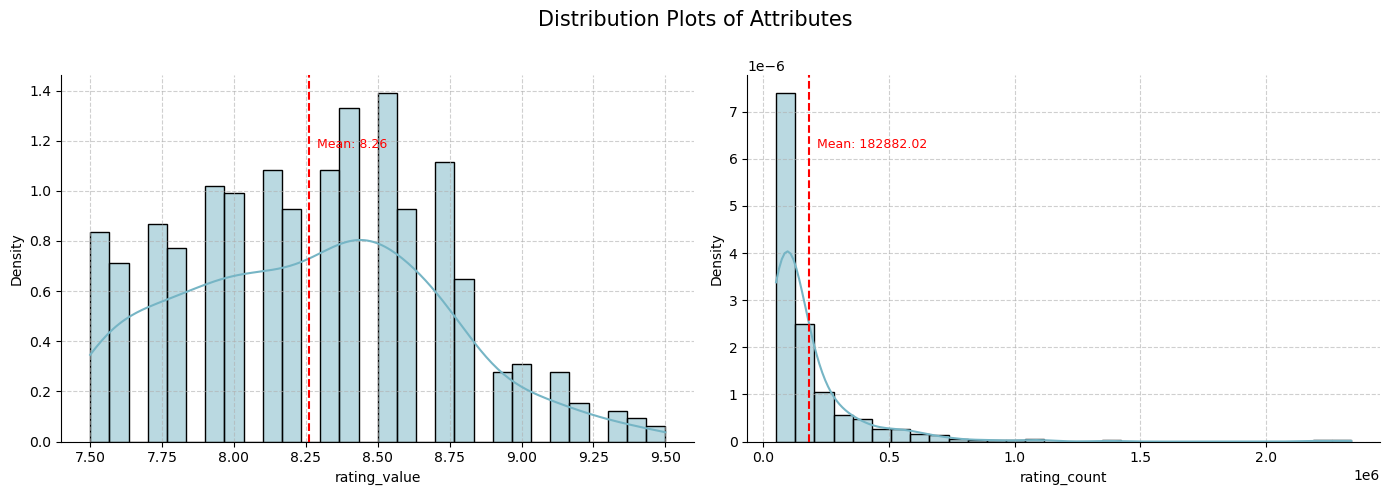

In [23]:
num_cols_eda = [n for n in tv_eda.columns if tv_eda[n].dtypes!='O']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax = ax.flatten()

for i, col in enumerate(num_cols_eda):
    sns.histplot(tv_eda[col],kde=True,stat='density',bins=30,ax=ax[i],color='#76b5c5')
    mean_val = tv_eda[col].mean()  
    ax[i].axvline(mean_val, color='red', linestyle='--')
    ax[i].text(mean_val, ax[i].get_ylim()[1] * 0.8, f'  Mean: {mean_val:.2f}', color='red', fontsize=9, ha='left')
    ax[i].grid(True, linestyle='--', alpha=0.6)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

fig.suptitle('Distribution Plots of Attributes', size=15)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

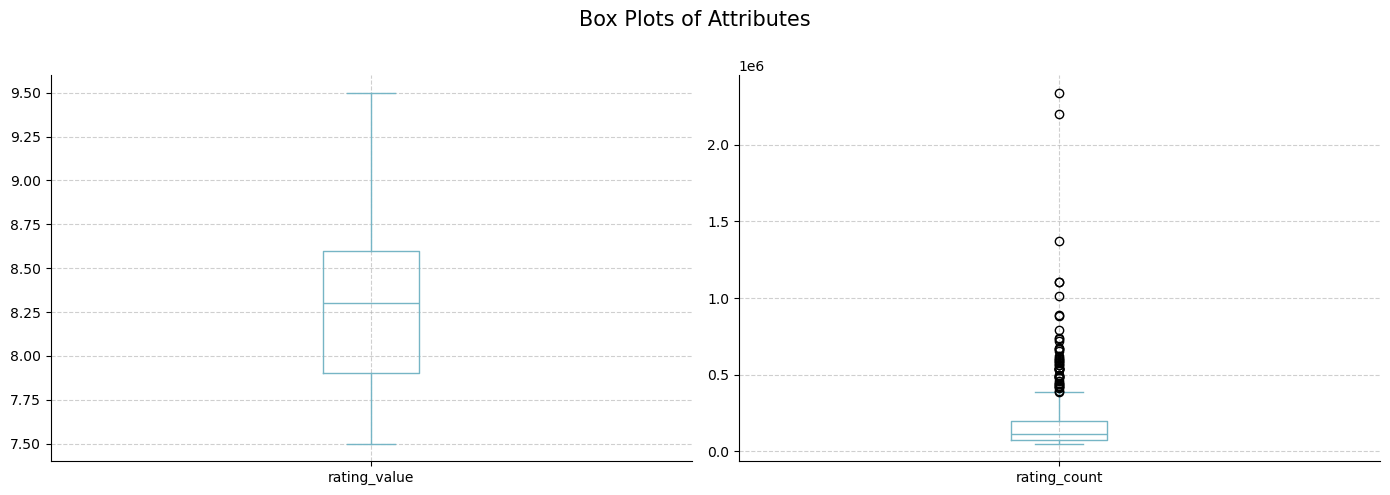

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax = ax.flatten()

for i, col in enumerate(num_cols_eda):
    tv_eda.boxplot(col, ax=ax[i],color='#76b5c5')
    ax[i].grid(True, linestyle='--', alpha=0.6)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

fig.suptitle('Box Plots of Attributes', size=15)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Exploratory Data Analysis (Categorical Variables)

In [25]:
name_counts = tv_eda['name'].value_counts()
duplicates_n = tv_eda[tv_eda['name'].isin(name_counts[name_counts > 1].index)]
duplicates_n

,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count
161,Twin Peaks,https://www.imdb.com/title/tt4093826/,https://m.media-amazon.com/images/M/MV5BZWZiNW...,M18,2017-05-21,Picks up 25 years after the inhabitants of a q...,"['Crime', 'Drama', 'Horror']","surrealism,gore,dream sequence,doppelganger,love","['Kyle MacLachlan', 'Sheryl Lee', 'Michael Hor...","['Mark Frost', 'David Lynch']",8.5,77595
190,Hagane no renkinjutsushi,https://www.imdb.com/title/tt1355642/,https://m.media-amazon.com/images/M/MV5BZmEzN2...,NC16,2010-02-13,Two brothers search for a Philosopher&apos;s S...,"['Animation', 'Action', 'Adventure']","alchemy,loss of limb,genocide,brother brother ...","['Kent Williams', 'Iemasa Kayumi', 'Matthew Le...",['Hiromu Arakawa'],9.1,204054
229,The Office,https://www.imdb.com/title/tt0386676/,https://m.media-amazon.com/images/M/MV5BMDNkOT...,PG,2005-03-24,A mockumentary on a group of typical office wo...,['Comedy'],"mockumentary,office,office romance,employer em...","['Steve Carell', 'Jenna Fischer', 'John Krasin...","['Greg Daniels', 'Ricky Gervais', 'Stephen Mer...",9.0,734195
265,The Office,https://www.imdb.com/title/tt0290978/,https://m.media-amazon.com/images/M/MV5BYWI2Ym...,NC-16,2001-07-09,The story of an office that faces closure when...,"['Comedy', 'Drama']","mockumentary,cringe comedy,office,sitcom,briti...","['Ricky Gervais', 'Martin Freeman', 'Mackenzie...","['Ricky Gervais', 'Stephen Merchant']",8.5,124726
324,Twin Peaks,https://www.imdb.com/title/tt0098936/,https://m.media-amazon.com/images/M/MV5BMTExNz...,PG,1990-04-08,An idiosyncratic FBI agent investigates the mu...,"['Crime', 'Drama', 'Mystery']","mysterious death,small town,murder,surrealism,...","['Kyle MacLachlan', 'Michael Ontkean', 'Mädche...","['Mark Frost', 'David Lynch']",8.8,219029
358,Battlestar Galactica,https://www.imdb.com/title/tt0314979/,https://m.media-amazon.com/images/M/MV5BNjYwYT...,NC-16,2003-12-08,Following the destruction of the Twelve Coloni...,"['Action', 'Adventure', 'Drama']","woman smokes a cigar,time dilation,woman wears...","['Edward James Olmos', 'Mary McDonnell', 'Kate...",[],8.5,81177
383,Battlestar Galactica,https://www.imdb.com/title/tt0407362/,https://m.media-amazon.com/images/M/MV5BZjBjMj...,PG,2005-01-14,"When an old enemy, the Cylons, resurface and o...","['Action', 'Adventure', 'Drama']","human in outer space,nuclear weapon,totalitari...","['Edward James Olmos', 'Mary McDonnell', 'Jami...","['Glen A. Larson', 'Ronald D. Moore']",8.7,177902
475,Hagane no renkinjutsushi,https://www.imdb.com/title/tt0421357/,https://m.media-amazon.com/images/M/MV5BNDczZW...,NC16,2017-12-31,When a failed alchemical ritual leaves brother...,"['Animation', 'Action', 'Adventure']","military,artificial human,supernatural power,s...","['Vic Mignogna', 'Aaron Dismuke', 'Romi Park']",[],8.5,79029


In [26]:
creator_counts = tv_eda['creators'].value_counts()
duplicates_c = tv_eda[(tv_eda['creators'].isin(creator_counts[creator_counts > 1].index)) & (tv_eda['creators'] != '[]')]
duplicates_c

,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count
17,Midnight Mass,https://www.imdb.com/title/tt10574558/,https://m.media-amazon.com/images/M/MV5BYWFjMD...,M18,2021-09-24,An isolated island community experiences mirac...,"['Drama', 'Fantasy', 'Horror']","vampire,island,religious fanaticism,community,...","['Kate Siegel', 'Zach Gilford', 'Kristin Lehman']",['Mike Flanagan'],7.7,149259
20,Star Trek: The Next Generation,https://www.imdb.com/title/tt0092455/,https://m.media-amazon.com/images/M/MV5BOWFhYj...,PG,2017-04-02,Set almost 100 years after Captain Kirk&apos;s...,"['Action', 'Adventure', 'Drama']","cult tv,famous opening theme,star trek,space e...","['Patrick Stewart', 'Brent Spiner', 'Jonathan ...",['Gene Roddenberry'],8.7,138736
27,The Newsroom,https://www.imdb.com/title/tt1870479/,https://m.media-amazon.com/images/M/MV5BNzk4Zj...,M18,2012-06-24,A newsroom undergoes some changes in its worki...,['Drama'],"newsroom,ethics,television producer,news repor...","['Jeff Daniels', 'Emily Mortimer', 'John Galla...",['Aaron Sorkin'],8.6,126352
28,Smallville,https://www.imdb.com/title/tt0279600/,https://m.media-amazon.com/images/M/MV5BYmNiNz...,PG,2001-10-16,A young Clark Kent struggles to find his place...,"['Action', 'Adventure', 'Drama']","adoption,adopted son,meteor shower,best friend...","['Tom Welling', 'Michael Rosenbaum', 'Allison ...","['Alfred Gough', 'Miles Millar']",7.5,140212
55,The Tudors,https://www.imdb.com/title/tt0758790/,https://m.media-amazon.com/images/M/MV5BNjlkOG...,R21,2007-04-01,Epic series reveals the scandalous life of a y...,"['Drama', 'History', 'Romance']","sex scene,king,royalty,king henry viii,english...","['Jonathan Rhys Meyers', 'Henry Cavill', 'Anth...",['Michael Hirst'],8.1,82301
...,...,...,...,...,...,...,...,...,...,...,...,...
413,Into the Badlands,https://www.imdb.com/title/tt3865236/,https://m.media-amazon.com/images/M/MV5BOGQzMW...,M18,2015-11-13,A mighty warrior and a young boy with supernat...,"['Action', 'Adventure', 'Drama']","post apocalypse,baron,warrior,martial arts,2010s","['Daniel Wu', 'Orla Brady', 'Emily Beecham']","['Alfred Gough', 'Miles Millar']",7.9,50232
441,Extras,https://www.imdb.com/title/tt0445114/,https://m.media-amazon.com/images/M/MV5BZDdlMz...,M18,2005-07-21,Andy Millman is an actor with ambition and a s...,"['Comedy', 'Drama']","cringe comedy,showbiz comedy,showbiz drama,sit...","['Ricky Gervais', 'Ashley Jensen', 'Stephen Me...","['Ricky Gervais', 'Stephen Merchant']",8.3,60933
446,Supernatural,https://www.imdb.com/title/tt0460681/,https://m.media-amazon.com/images/M/MV5BMDFmMG...,M18,2005-09-13,Two brothers follow their father&apos;s footst...,"['Drama', 'Fantasy', 'Horror']","brotherly love,ghost,demon hunter,vampire,demon","['Jared Padalecki', 'Jensen Ackles', 'Jim Beav...",['Eric Kripke'],8.4,492558
448,Stargate Universe,https://www.imdb.com/title/tt1286039/,https://m.media-amazon.com/images/M/MV5BOTEzNT...,M18,2009-10-02,Trapped on an Ancient spaceship billions of li...,"['Drama', 'Sci-Fi']","spaceship,shared universe,psychotronic series,...","['Robert Carlyle', 'Louis Ferreira', 'Brian J....","['Robert C. Cooper', 'Brad Wright']",7.6,53656


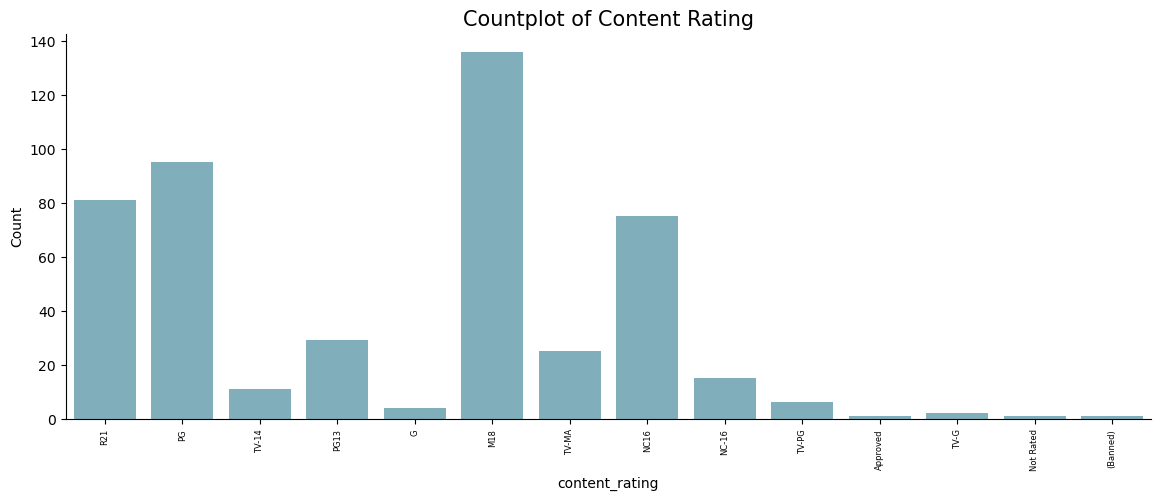

In [27]:
plt.figure(figsize=(14, 5))
ax = sns.countplot(x='content_rating', data=tv_eda, color='#76b5c5')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.ylabel('Count')
plt.title('Countplot of Content Rating',size=15)
plt.show()

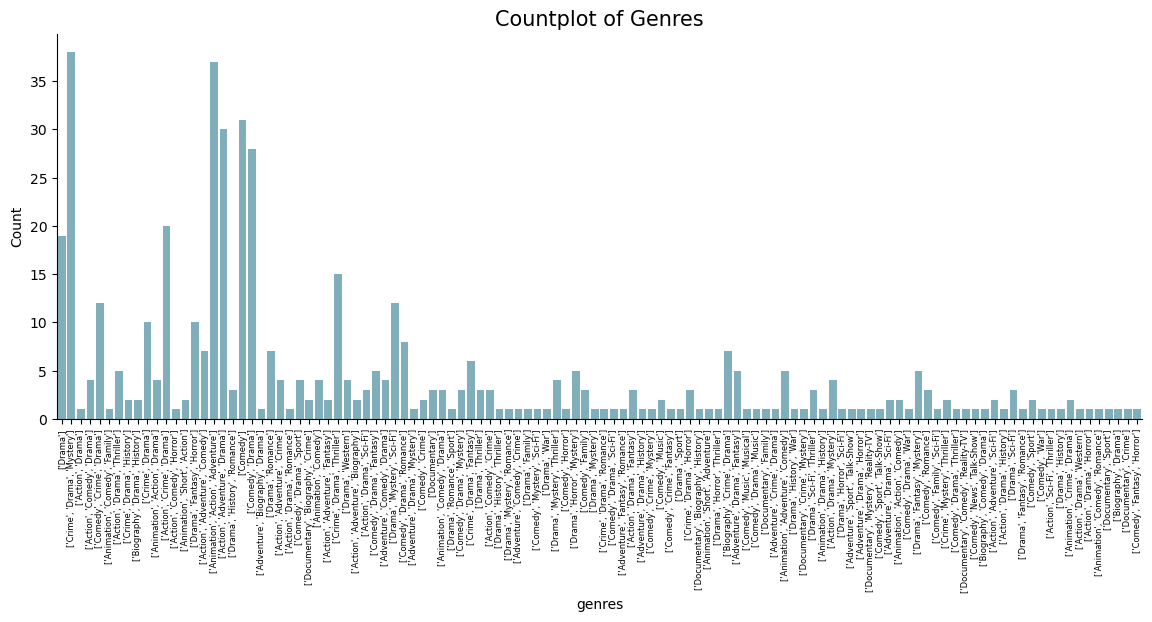

In [28]:
plt.figure(figsize=(14, 5))
ax = sns.countplot(x='genres', data=tv_eda, color='#76b5c5')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.ylabel('Count')
plt.title('Countplot of Genres',size=15)
plt.show()

## Exploratory Data Analysis (Missing Values)

In [29]:
tv_eda[tv_eda['content_rating'].isnull() == True]

,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count
242,The Heroes,https://www.imdb.com/title/tt7657124/,https://m.media-amazon.com/images/M/MV5BNDYwOT...,NaN,NaN,The moral stories of a group of champions (Pah...,"['Animation', 'Drama', 'History']","hero,iran,14th century,alternate history,pahle...","['Ali Hemmat Momivand', 'Shahrooz Malek Arayi'...",[],8.4,168365
414,Sandeep Bhaiya,https://www.imdb.com/title/tt28227737/,https://m.media-amazon.com/images/M/MV5BMzM5MT...,NaN,2023-06-30,A tiffin service provider finds a mentor in a ...,['Drama'],NaN,"['Sunny Hinduja', 'Deepali Gautam', 'Punit Tiw...",[],9.1,75661
424,Sapne Vs Everyone,https://www.imdb.com/title/tt30263074/,https://m.media-amazon.com/images/M/MV5BODI2OT...,NaN,2023-12-08,Two obsessive dreamers collide with the resist...,['Drama'],NaN,"['Paramvir Cheema', 'Ambrish Verma', 'Naveen K...",[],9.4,69735


In [30]:
tv_eda[tv_eda['date_published'].isnull() == True]

,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count
33,The Good Wife,https://www.imdb.com/title/tt1442462/,https://m.media-amazon.com/images/M/MV5BMTI2OT...,NC-16,NaN,Alicia Florrick has been a good wife to her hu...,"['Crime', 'Drama', 'Mystery']","female protagonist,law firm,corruption,courtro...","['Julianna Margulies', 'Chris Noth', 'Josh Cha...","['Michelle King', 'Robert King']",8.4,84002
242,The Heroes,https://www.imdb.com/title/tt7657124/,https://m.media-amazon.com/images/M/MV5BNDYwOT...,NaN,NaN,The moral stories of a group of champions (Pah...,"['Animation', 'Drama', 'History']","hero,iran,14th century,alternate history,pahle...","['Ali Hemmat Momivand', 'Shahrooz Malek Arayi'...",[],8.4,168365


In [31]:
tv_eda[tv_eda['keywords'].isnull() == True]

,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count
414,Sandeep Bhaiya,https://www.imdb.com/title/tt28227737/,https://m.media-amazon.com/images/M/MV5BMzM5MT...,NaN,2023-06-30,A tiffin service provider finds a mentor in a ...,['Drama'],NaN,"['Sunny Hinduja', 'Deepali Gautam', 'Punit Tiw...",[],9.1,75661
424,Sapne Vs Everyone,https://www.imdb.com/title/tt30263074/,https://m.media-amazon.com/images/M/MV5BODI2OT...,NaN,2023-12-08,Two obsessive dreamers collide with the resist...,['Drama'],NaN,"['Paramvir Cheema', 'Ambrish Verma', 'Naveen K...",[],9.4,69735


## Data Preprocessing

In [32]:
tv_data.loc[424, 'content_rating'] = 'TV-MA'
tv_data.loc[414, 'content_rating'] = 'NC16'
tv_data.loc[242, 'content_rating'] = 'TV-PG'

tv_data['content_rating'].isnull().sum()

0

In [33]:
tv_data['year_released'] = tv_data['date_published'].str[:4]

tv_data['year_released'].isnull().sum()

2

In [34]:
tv_data.loc[242, 'year_released'] = 2008
tv_data.loc[33, 'year_released'] = 2009

tv_data['year_released'].isnull().sum()

0

In [35]:
tv_data['keywords'] = tv_data['keywords'].fillna(value='')

tv_data['keywords'].isnull().sum()

0

In [36]:
name_counts = tv_eda['name'].value_counts()
duplicate_names = name_counts[name_counts > 1].index

tv_data['name'] = tv_data.apply(
    lambda row: row['name'] + ' (' + str(row['year_released']) + ')' 
                if row['name'] in duplicate_names else row['name'], axis=1
)

In [37]:
title_counts = tv_data['name'].value_counts()
duplicates_t = tv_eda[tv_data['name'].isin(title_counts[title_counts > 1].index)]
duplicates_t

,name,url,image,content_rating,date_published,description,genres,keywords,stars,creators,rating_value,rating_count


In [38]:
tv_data['year_released'] = pd.to_numeric(tv_data['year_released'], errors='coerce')
tv_data['decade_released'] = (tv_data['year_released'] // 10) * 10

In [39]:
rating_mapping = {
    'G': 1,
    'TV-G': 1,
    'PG': 2,
    'TV-PG': 2,
    'PG13': 2,
    'TV-14': 2,
    'Approved': 3,
    'NC16': 3,
    'NC-16': 3,
    'TV-16': 3,
    'M18': 3,
    'TV-MA': 3,
    'Not Rated': 3,
    'R21': 4,
    '(Banned)': 4
}

tv_data['content_rating_encoded'] = tv_data['content_rating'].map(rating_mapping)

In [40]:
tv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    485 non-null    object 
 1   url                     485 non-null    object 
 2   image                   485 non-null    object 
 3   content_rating          485 non-null    object 
 4   date_published          483 non-null    object 
 5   description             485 non-null    object 
 6   genres                  485 non-null    object 
 7   keywords                485 non-null    object 
 8   stars                   485 non-null    object 
 9   creators                485 non-null    object 
 10  rating_value            485 non-null    float64
 11  rating_count            485 non-null    int64  
 12  year_released           485 non-null    int64  
 13  decade_released         485 non-null    int64  
 14  content_rating_encoded  485 non-null    in

In [41]:
tv_data = tv_data.drop(columns=['content_rating','date_published','year_released'])

In [42]:
tv_data.head()

,name,url,image,description,genres,keywords,stars,creators,rating_value,rating_count,decade_released,content_rating_encoded
0,Euphoria,https://www.imdb.com/title/tt8772296/,https://m.media-amazon.com/images/M/MV5BMDMzZD...,"Rue Bennett is a drug addict fresh from rehab,...",['Drama'],"drug addict,high school,sex scene,male full fr...","['Zendaya', 'Hunter Schafer', 'Jacob Elordi']",['Sam Levinson'],8.3,253260,2010,4
1,Veronica Mars,https://www.imdb.com/title/tt0412253/,https://m.media-amazon.com/images/M/MV5BNWJjM2...,"After her best friend is murdered, and her fat...","['Crime', 'Drama', 'Mystery']","female protagonist,female detective,female pri...","['Kristen Bell', 'Jason Dohring', 'Enrico Cola...",['Rob Thomas'],8.4,78853,2000,2
2,Chicago Fire,https://www.imdb.com/title/tt2261391/,https://m.media-amazon.com/images/M/MV5BYzhjMj...,The story of firefighters and paramedics in th...,"['Action', 'Drama']","gay character,fire department,firefighter,resc...","['Taylor Kinney', 'Christian Stolte', 'Eamonn ...","['Michael Brandt', 'Derek Haas']",8.0,66204,2010,2
3,Chuck,https://www.imdb.com/title/tt0934814/,https://m.media-amazon.com/images/M/MV5BMTM0OD...,When a computer geek inadvertently downloads c...,"['Action', 'Comedy', 'Drama']","character name as series title,nsa,male protag...","['Zachary Levi', 'Yvonne Strahovski', 'Joshua ...","['Chris Fedak', 'Josh Schwartz']",8.2,148288,2000,2
4,Castle,https://www.imdb.com/title/tt1219024/,https://m.media-amazon.com/images/M/MV5BMjM2Nj...,When a psychopath commits murders based on nov...,"['Comedy', 'Crime', 'Drama']","female detective,new york city,homicide invest...","['Nathan Fillion', 'Stana Katic', 'Susan Sulli...",['Andrew W. Marlowe'],8.1,176447,2000,2


In [43]:
# Lowercase these columns
tv_data[['description', 'genres', 'keywords', 'stars', 'creators']] = tv_data[['description', 'genres', 'keywords', 'stars', 'creators']].apply(
    lambda x: x.str.lower())

In [44]:
tv_data.head()

,name,url,image,description,genres,keywords,stars,creators,rating_value,rating_count,decade_released,content_rating_encoded
0,Euphoria,https://www.imdb.com/title/tt8772296/,https://m.media-amazon.com/images/M/MV5BMDMzZD...,"rue bennett is a drug addict fresh from rehab,...",['drama'],"drug addict,high school,sex scene,male full fr...","['zendaya', 'hunter schafer', 'jacob elordi']",['sam levinson'],8.3,253260,2010,4
1,Veronica Mars,https://www.imdb.com/title/tt0412253/,https://m.media-amazon.com/images/M/MV5BNWJjM2...,"after her best friend is murdered, and her fat...","['crime', 'drama', 'mystery']","female protagonist,female detective,female pri...","['kristen bell', 'jason dohring', 'enrico cola...",['rob thomas'],8.4,78853,2000,2
2,Chicago Fire,https://www.imdb.com/title/tt2261391/,https://m.media-amazon.com/images/M/MV5BYzhjMj...,the story of firefighters and paramedics in th...,"['action', 'drama']","gay character,fire department,firefighter,resc...","['taylor kinney', 'christian stolte', 'eamonn ...","['michael brandt', 'derek haas']",8.0,66204,2010,2
3,Chuck,https://www.imdb.com/title/tt0934814/,https://m.media-amazon.com/images/M/MV5BMTM0OD...,when a computer geek inadvertently downloads c...,"['action', 'comedy', 'drama']","character name as series title,nsa,male protag...","['zachary levi', 'yvonne strahovski', 'joshua ...","['chris fedak', 'josh schwartz']",8.2,148288,2000,2
4,Castle,https://www.imdb.com/title/tt1219024/,https://m.media-amazon.com/images/M/MV5BMjM2Nj...,when a psychopath commits murders based on nov...,"['comedy', 'crime', 'drama']","female detective,new york city,homicide invest...","['nathan fillion', 'stana katic', 'susan sulli...",['andrew w. marlowe'],8.1,176447,2000,2


In [45]:
columns_with_apos = [col for col in tv_data.columns if tv_data[col].astype(str).str.contains('&apos;').any()]

print(columns_with_apos)

['name', 'description', 'keywords', 'stars', 'creators']


In [46]:
for col in columns_with_apos:
    tv_data[col] = tv_data[col].astype(str).str.replace("&apos;", "'")

In [47]:
columns_with_apos = [col for col in tv_data.columns if tv_data[col].astype(str).str.contains('&apos;').any()]

print(columns_with_apos)

[]


In [48]:
columns_with_amp = [col for col in tv_data.columns if tv_data[col].astype(str).str.contains('&amp;').any()]

print(columns_with_amp)

['name', 'description']


In [49]:
for col in columns_with_amp:
    tv_data[col] = tv_data[col].astype(str).str.replace("&amp;", "&")

In [50]:
columns_with_amp = [col for col in tv_data.columns if tv_data[col].astype(str).str.contains('&amp;').any()]

print(columns_with_amp)

[]


In [51]:
tv_data['description'] = tv_data['description'].apply(lambda x: re.sub(r'\W+', ' ', x))
tv_data['genres'] = tv_data['genres'].apply(lambda x: re.sub(r'\W+', ' ', x))
tv_data['keywords'] = tv_data['keywords'].apply(lambda x: re.sub(r'\W+', ' ', x))
tv_data['stars'] = tv_data['stars'].apply(lambda x: re.sub(r'\W+', ' ', x))
tv_data['creators'] = tv_data['creators'].apply(lambda x: re.sub(r'\W+', ' ', x))

In [52]:
tv_data.head()

,name,url,image,description,genres,keywords,stars,creators,rating_value,rating_count,decade_released,content_rating_encoded
0,Euphoria,https://www.imdb.com/title/tt8772296/,https://m.media-amazon.com/images/M/MV5BMDMzZD...,rue bennett is a drug addict fresh from rehab ...,drama,drug addict high school sex scene male full fr...,zendaya hunter schafer jacob elordi,sam levinson,8.3,253260,2010,4
1,Veronica Mars,https://www.imdb.com/title/tt0412253/,https://m.media-amazon.com/images/M/MV5BNWJjM2...,after her best friend is murdered and her fath...,crime drama mystery,female protagonist female detective female pri...,kristen bell jason dohring enrico colantoni,rob thomas,8.4,78853,2000,2
2,Chicago Fire,https://www.imdb.com/title/tt2261391/,https://m.media-amazon.com/images/M/MV5BYzhjMj...,the story of firefighters and paramedics in th...,action drama,gay character fire department firefighter resc...,taylor kinney christian stolte eamonn walker,michael brandt derek haas,8.0,66204,2010,2
3,Chuck,https://www.imdb.com/title/tt0934814/,https://m.media-amazon.com/images/M/MV5BMTM0OD...,when a computer geek inadvertently downloads c...,action comedy drama,character name as series title nsa male protag...,zachary levi yvonne strahovski joshua gomez,chris fedak josh schwartz,8.2,148288,2000,2
4,Castle,https://www.imdb.com/title/tt1219024/,https://m.media-amazon.com/images/M/MV5BMjM2Nj...,when a psychopath commits murders based on nov...,comedy crime drama,female detective new york city homicide invest...,nathan fillion stana katic susan sullivan,andrew w marlowe,8.1,176447,2000,2


In [53]:
stop_words = set(stopwords.words('english'))

In [54]:
tv_data['description'] = tv_data['description'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))
tv_data['genres'] = tv_data['genres'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))
tv_data['keywords'] = tv_data['keywords'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))
tv_data['stars'] = tv_data['stars'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))
tv_data['creators'] = tv_data['creators'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

In [55]:
tv_data.head()

,name,url,image,description,genres,keywords,stars,creators,rating_value,rating_count,decade_released,content_rating_encoded
0,Euphoria,https://www.imdb.com/title/tt8772296/,https://m.media-amazon.com/images/M/MV5BMDMzZD...,rue bennett drug addict fresh rehab struggling...,drama,drug addict high school sex scene male full fr...,zendaya hunter schafer jacob elordi,sam levinson,8.3,253260,2010,4
1,Veronica Mars,https://www.imdb.com/title/tt0412253/,https://m.media-amazon.com/images/M/MV5BNWJjM2...,best friend murdered father removed county she...,crime drama mystery,female protagonist female detective female pri...,kristen bell jason dohring enrico colantoni,rob thomas,8.4,78853,2000,2
2,Chicago Fire,https://www.imdb.com/title/tt2261391/,https://m.media-amazon.com/images/M/MV5BYzhjMj...,story firefighters paramedics city chicago per...,action drama,gay character fire department firefighter resc...,taylor kinney christian stolte eamonn walker,michael brandt derek haas,8.0,66204,2010,2
3,Chuck,https://www.imdb.com/title/tt0934814/,https://m.media-amazon.com/images/M/MV5BMTM0OD...,computer geek inadvertently downloads critical...,action comedy drama,character name series title nsa male protagoni...,zachary levi yvonne strahovski joshua gomez,chris fedak josh schwartz,8.2,148288,2000,2
4,Castle,https://www.imdb.com/title/tt1219024/,https://m.media-amazon.com/images/M/MV5BMjM2Nj...,psychopath commits murders based novelist cast...,comedy crime drama,female detective new york city homicide invest...,nathan fillion stana katic susan sullivan,andrew w marlowe,8.1,176447,2000,2


In [56]:
tv_data['aggregated_text'] = tv_data.apply(lambda row: ' '.join([
    str(row['description']),
    str(row['genres']),
    str(row['keywords']),
    str(row['stars']),
    str(row['creators']),
    str(row['decade_released']),
    str(row['content_rating_encoded'])
]), axis=1)

In [57]:
tv_data_processed = tv_data[['name','url','image','rating_value','rating_count','aggregated_text']]

In [58]:
tv_data_processed.to_csv('tv_data_processed.csv',index=False)

In [59]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(tv_data_processed['aggregated_text'])

In [60]:
cosine_sim_t = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [61]:
count_vect = CountVectorizer()
count_matrix = count_vect.fit_transform(tv_data_processed['aggregated_text'])

In [62]:
cosine_sim_c = cosine_similarity(count_matrix, count_matrix)

In [63]:
def get_recommendations(title, cosine_sim):
    # Escape the title to avoid regex issues
    escaped_title = re.escape(title)
    
    # Getting the index of the tv show that matches the title
    matches = tv_data_processed[tv_data_processed['name'].str.contains(escaped_title, case=False)]
    
    # Check if there are matches
    if matches.empty:
        print(f"No match found for title: {title}")
        return []

    id = matches.index[0]

    sim_scores = list(enumerate(cosine_sim[id]))

    # Sort the tv shows based on similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the indices of the top 10 most similar shows/movies (excluding itself)
    sim_scores = sim_scores[1:11]  # Skip the first entry since it's the same tv show

    # Get the titles of the top 10 most similar tv shows
    similar_titles = [tv_data_processed['name'].iloc[i[0]] for i in sim_scores]

    return similar_titles

In [64]:
get_recommendations('You',cosine_sim_t)

['Peep Show',
 'Planet Earth II',
 'American Crime Story',
 'Seinfeld',
 'Mr. Bean',
 'M*A*S*H',
 "Chappelle's Show",
 'Frasier',
 'Planet Earth',
 'Black Bird']

In [65]:
get_recommendations('You',cosine_sim_c)

['Peep Show',
 'Mr. Bean',
 'Frasier',
 'Planet Earth',
 'Planet Earth II',
 'The Inbetweeners',
 'Only Fools and Horses',
 "Chappelle's Show",
 'Boston Legal',
 'Extras']

In [66]:
get_recommendations('Suits',cosine_sim_t)

['Master of None',
 'Friends',
 'Seinfeld',
 'Mad Men',
 'Flight of the Conchords',
 'The Alienist',
 '30 Rock',
 'Better Call Saul',
 'Daredevil',
 'Elementary']

In [67]:
get_recommendations('Suits',cosine_sim_c)

['Master of None',
 'Seinfeld',
 'Friends',
 'Flight of the Conchords',
 'Mad Men',
 'The Alienist',
 '30 Rock',
 'Elementary',
 'The Marvelous Mrs. Maisel',
 'The Punisher']

In [68]:
get_recommendations('Breaking Bad',cosine_sim_t)

['Better Call Saul',
 'Narcos',
 'The Wire',
 'Your Honor',
 'Ozark',
 'Malcolm in the Middle',
 'New Amsterdam',
 'Dead to Me',
 'Suits',
 'Euphoria']

In [69]:
get_recommendations('Breaking Bad',cosine_sim_c)

['Your Honor',
 'Narcos',
 'The Wire',
 'Ozark',
 'Mayor of Kingstown',
 'Better Call Saul',
 'Limitless',
 'Euphoria',
 'Suits',
 'Anne']